<a href="https://colab.research.google.com/github/manavka/DeepFashion_DS207/blob/main/CNN_cropped.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from keras_hub.models import EfficientNetBackbone
import keras
import shap
from sklearn.metrics import ConfusionMatrixDisplay
import zipfile

from google.colab import drive
drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/207_Final/DeepFashion/Category and Attribute Prediction Benchmark")

# Optimize
tf.config.optimizer.set_jit(True)

Mounted at /content/drive


In [2]:
# Unzip images

img_dir = "/content/DeepFashion_img/img"
prepend_path = "/content/DeepFashion_img/" # use later
drive_img_dir = os.path.join(os.getcwd(), "Img") # where img.zip lives in Drive

if not os.path.exists(img_dir):
    with zipfile.ZipFile(os.path.join(drive_img_dir, "img.zip"), 'r') as zip_ref:
        zip_ref.extractall(prepend_path)

In [3]:
# for fine annotations
fine_lookup_df = pd.read_csv(
    "./Anno_fine/list_attr_cloth.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    skiprows=1,      # skip the first line (289222)
    header=0         # use the second line as header
)

my_headers = list(fine_lookup_df['attribute_name'].unique())
print(my_headers)

# key is attribute type number, value is string, use a lambda function to assign this to a new column in the fine_label_df
attribute_to_string_dict = {1: 'pattern', 2: 'sleeve style', 3: 'dress type', 4: 'neckline', 5: 'material', 6:'fit'}
fine_lookup_df['attribute_type_str'] = fine_lookup_df['attribute_type'].apply(lambda x: attribute_to_string_dict[x])
fine_lookup_df.set_index('attribute_name', inplace=True)# for easy lookup later

fine_label_df = pd.read_csv(
    "./Anno_fine/train_attr.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    #skiprows=1,      # skip the first line (289222)
    names=my_headers        # use the second line as header
)

fine_train_image_name_df = pd.read_csv(
    "./Anno_fine/train.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    #skiprows=1,      # skip the first line (289222)
    names = ['img_name']      # use the second line as header
)

fine_category_train_df = pd.read_csv(
    "./Anno_fine/train_cate.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    #skiprows=1,      # skip the first line (289222)
    names = ['category']      # use the second line as header
)

fine_category_lookup_df = pd.read_csv("./Anno_fine/list_category_cloth.txt",
                                       sep=r"\s+", skiprows=1, header=0)
fine_category_lookup_df['key'] = fine_category_lookup_df.index+1

train_df = pd.concat([fine_train_image_name_df, fine_label_df], axis=1)

train_df_with_category = pd.concat([fine_train_image_name_df, fine_category_train_df], axis=1)
train_df_with_category = train_df_with_category.merge(fine_category_lookup_df, left_on='category', right_on='key', how='left')
train_df_with_category['category_type_tf'] = train_df_with_category['category_type']-1 # Tensorflow expects 0-based indexing for categorical labels


# Validation set
fine_val_image_name_df = pd.read_csv(
    "./Anno_fine/val.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    names = ['img_name']      # use the second line as header
)

fine_category_val_df = pd.read_csv(
    "./Anno_fine/val_cate.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    names = ['category']      # use the second line as header
)

val_df = pd.concat([fine_val_image_name_df, fine_label_df], axis=1)

val_df_with_category = pd.concat([fine_val_image_name_df, fine_category_val_df], axis=1)
val_df_with_category = val_df_with_category.merge(fine_category_lookup_df, left_on='category', right_on='key', how='left')
val_df_with_category['category_type_tf'] = val_df_with_category['category_type']-1 # Tensorflow expects 0-based indexing for categorical labels

# Test Set
fine_test_image_name_df = pd.read_csv(
    "./Anno_fine/test.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    names = ['img_name']      # use the second line as header
)

fine_category_test_df = pd.read_csv(
    "./Anno_fine/test_cate.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    names = ['category']      # use the second line as header
)

test_df = pd.concat([fine_test_image_name_df, fine_label_df], axis=1)

test_df_with_category = pd.concat([fine_test_image_name_df, fine_category_test_df], axis=1)
test_df_with_category = test_df_with_category.merge(fine_category_lookup_df, left_on='category', right_on='key', how='left')
test_df_with_category['category_type_tf'] = test_df_with_category['category_type']-1 # Tensorflow expects 0-based indexing for categorical labels

fine_category_lookup_df.set_index('category_name', inplace=True)# for lookup later
category_dict = {1: 'upper body', 2: 'lower body', 3: 'full body'}
fine_category_lookup_df['category_type_str'] = fine_category_lookup_df['category_type'].apply(lambda x: category_dict[x])

['floral', 'graphic', 'striped', 'embroidered', 'pleated', 'solid', 'lattice', 'long_sleeve', 'short_sleeve', 'sleeveless', 'maxi_length', 'mini_length', 'no_dress', 'crew_neckline', 'v_neckline', 'square_neckline', 'no_neckline', 'denim', 'chiffon', 'cotton', 'leather', 'faux', 'knit', 'tight', 'loose', 'conventional']


In [4]:
# Bounding boxes
bbox_train= pd.read_csv('./Anno_coarse/list_bbox.txt',sep=r"\s+", skiprows=1, header=0,)

# In bbox location, "x_1" and "y_1" represent the upper left point coordinate of bounding box, "x_2" and "y_2" represent the lower right point coordinate of bounding box. Bounding box locations are listed in the order of [x_1, y_1, x_2, y_2].
bbox_train['height'] = bbox_train['y_2'] - bbox_train['y_1']
bbox_train['width'] = bbox_train['x_2'] - bbox_train['x_1']
bbox_train

,image_name,x_1,y_1,x_2,y_2,height,width
0,img/Sheer_Pleated-Front_Blouse/img_00000001.jpg,72,79,232,273,194,160
1,img/Sheer_Pleated-Front_Blouse/img_00000002.jpg,67,59,155,161,102,88
2,img/Sheer_Pleated-Front_Blouse/img_00000003.jpg,65,65,156,200,135,91
3,img/Sheer_Pleated-Front_Blouse/img_00000004.jpg,51,62,167,182,120,116
4,img/Sheer_Pleated-Front_Blouse/img_00000005.jpg,46,88,166,262,174,120
...,...,...,...,...,...,...,...
289217,img/Paisley_Print_Babydoll_Dress/img_00000050.jpg,1,1,300,300,299,299
289218,img/Paisley_Print_Babydoll_Dress/img_00000051.jpg,14,58,225,277,219,211
289219,img/Paisley_Print_Babydoll_Dress/img_00000052.jpg,18,41,149,230,189,131
289220,img/Paisley_Print_Babydoll_Dress/img_00000053.jpg,75,47,220,300,253,145


In [5]:
# define load image function
IMG_SIZE = (224, 224)

def load_image(path, label):
    '''
    Load image and scale to 0-1 range. Then resize to IMG_SIZE(Not necessary as all images are the same size)
    '''
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label


def load_image_cropped(path, bbox, label):
    '''
    Load image, crop it to bbox and scale to 0-1 range. Then resize to IMG_SIZE(Not necessary as all images are the same size)
    '''
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    y = bbox[1]
    x = bbox[0]
    h = bbox[2]
    w = bbox[3]

    cropped = tf.image.crop_to_bounding_box(img, y, x, h, w)
    cropped = tf.image.resize(cropped, IMG_SIZE)
    cropped = cropped / 255.0

    return cropped, label


<h1>Forming Train, Test and Validation Datasets</h1>

In [7]:
# Crop all datasets

batch_size = 64

# Crop training dataset
bbox_train_split = bbox_train.merge(train_df_with_category[['img_name', 'category_type_tf']], left_on='image_name', right_on='img_name', how='inner', suffixes=('_bbox', '_category'))
bbox_train_split[['x_1', 'y_1', 'height', 'width']] = bbox_train_split[['x_1', 'y_1', 'height', 'width']].astype('int32')
train_files = bbox_train_split['image_name'].tolist()
if prepend_path: # Add new path to images
    train_files = [prepend_path + path for path in train_files]
train_bboxes = bbox_train_split[['x_1', 'y_1', 'height', 'width']].values
train_labels = bbox_train_split['category_type_tf'].tolist()

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_bboxes, train_labels))
    .map(load_image_cropped, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(len(train_files))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# Crop validation dataset
bbox_val_split = bbox_train.merge(val_df_with_category[['img_name', 'category_type_tf']], left_on='image_name', right_on='img_name', how='inner', suffixes=('_bbox', '_category'))
bbox_val_split[['x_1', 'y_1', 'height', 'width']] = bbox_val_split[['x_1', 'y_1', 'height', 'width']].astype('int32')
val_files = bbox_val_split['image_name'].tolist()
if prepend_path: # Add new path to images
    val_files = [prepend_path + path for path in val_files]
val_bboxes = bbox_val_split[['x_1', 'y_1', 'height', 'width']].values
val_labels = bbox_val_split['category_type_tf'].tolist()

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_bboxes, val_labels))
    .map(load_image_cropped, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# Crop test dataset
bbox_test_split = bbox_train.merge(test_df_with_category[['img_name', 'category_type_tf']], left_on='image_name', right_on='img_name', how='inner', suffixes=('_bbox', '_category'))
bbox_test_split[['x_1', 'y_1', 'height', 'width']] = bbox_test_split[['x_1', 'y_1', 'height', 'width']].astype('int32')
test_files = bbox_test_split['image_name'].tolist()
if prepend_path: # Add new path to images
    test_files = [prepend_path + path for path in test_files]
test_bboxes = bbox_test_split[['x_1', 'y_1', 'height', 'width']].values
test_labels = bbox_test_split['category_type_tf'].tolist()

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_files, test_bboxes, test_labels))
    .map(load_image_cropped, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# Confirm all images were cropped for each dataset (all should be true)
print(f"Train: {len(train_files) == len(train_df_with_category)}")
print(f"Val: {len(val_files) == len(val_df_with_category)}")
print(f"Test: {len(test_files) == len(test_df_with_category)}")

Train: True
Val: True
Test: True


<h1> Define Model </h1>

In [8]:
# Augment training images
# Flip, rotate, zoom, contrast
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [9]:
IMG_SIZE

(224, 224)

In [10]:
NUM_CLASSES = 3
def make_custom_cnn(input_shape=IMG_SIZE + (3,), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)

    # Block 1
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Block 4
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)


    # Block 5
    x = layers.Conv2D(512, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(512, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="custom_cnn_garment")
    return model

model = make_custom_cnn()
model.summary()


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),#1e-3
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],

)

Model: "custom_cnn_garment"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 4,786,211 (18.26 MB)

 Trainable params: 4,782,243 (18.24 MB)

 Non-trainable params: 3,968 (15.50 KB)

<h1>Train Model</h1>

In [11]:
es = callback = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy',
                                              patience=5, restore_best_weights=True)# add learning rate scheduler

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.2,       # New LR = old LR * factor
    patience=3,        # Number of epochs to wait before dropping LR
    min_lr=1e-7        # Boundary limit
)


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=[es, reduce_lr]
)

Epoch 1/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 159s 498ms/step - accuracy: 0.5053 - loss: 1.0782 - val_accuracy: 0.4390 - val_loss: 1.0732 - learning_rate: 0.0010
Epoch 2/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 126s 556ms/step - accuracy: 0.6845 - loss: 0.7417 - val_accuracy: 0.4925 - val_loss: 1.1326 - learning_rate: 0.0010
Epoch 3/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 91s 397ms/step - accuracy: 0.7608 - loss: 0.5839 - val_accuracy: 0.6190 - val_loss: 1.0985 - learning_rate: 0.0010
Epoch 4/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 91s 397ms/step - accuracy: 0.8071 - loss: 0.4918 - val_accuracy: 0.6590 - val_loss: 0.8817 - learning_rate: 0.0010
Epoch 5/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 91s 397ms/step - accuracy: 0.8277 - loss: 0.4350 - val_accuracy: 0.6745 - val_loss: 0.7826 - learning_rate: 0.0010
Epoch 6/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 91s 397ms/step - accuracy: 0.8492 - loss: 0.3924 - val_accuracy: 0.6685 - val_loss: 0.8639 - learning_rate: 0.0010
Epoch 7/40
219/219 ━━━━━━━━━━━━━━━━━━━━ 92s 397ms/step - accuracy: 0

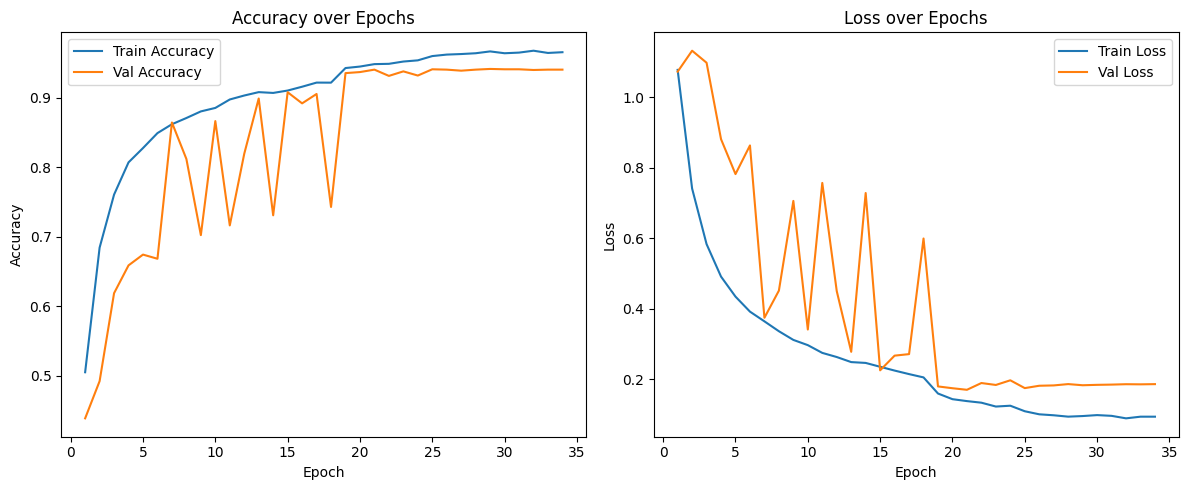

In [12]:
# Plot accuracy and loss over epochs
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(accuracy) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs_range, accuracy, label='Train Accuracy')
axes[0].plot(epochs_range, val_accuracy, label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(epochs_range, loss, label='Train Loss')
axes[1].plot(epochs_range, val_loss, label='Val Loss')
axes[1].set_title('Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate model on validation set
model.evaluate(val_ds, return_dict=True)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.9365 - loss: 0.1908


{'accuracy': 0.9365000128746033, 'loss': 0.19081024825572968}

In [ ]:
# Evaluate model on test set

model.evaluate(test_ds)


63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - accuracy: 0.9315 - loss: 0.1753


[0.17530307173728943, 0.9315000176429749]

In [ ]:
# Save model
model.save('/content/drive/MyDrive/207_Final/CNN_cropped.keras')

<h1>See what the model struggles to predict</h1>
Uses validation data

Finding misclassified images...
Found 117 misclassified images out of 2000.

Displaying a few misclassified images:


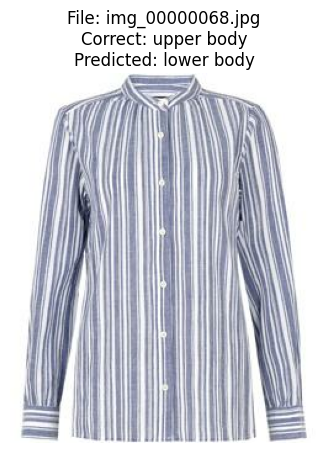

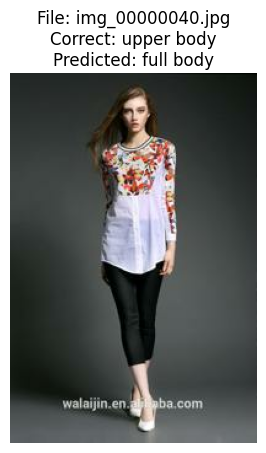

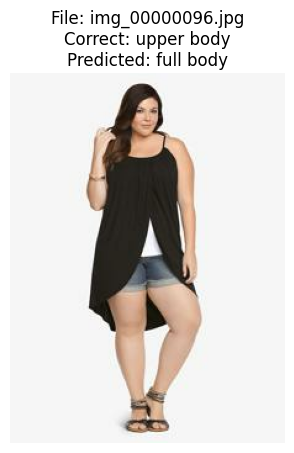

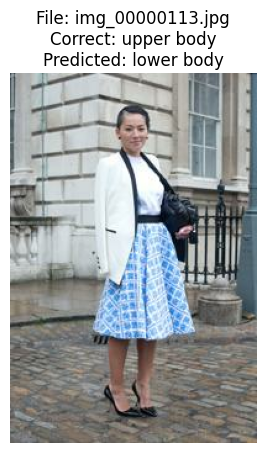

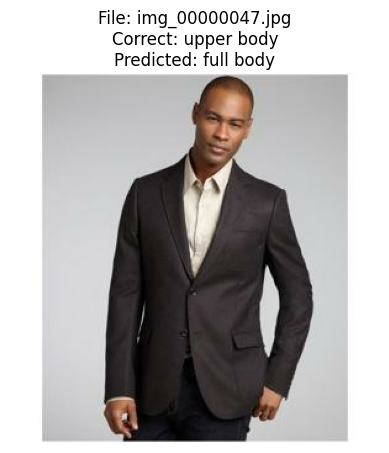

In [13]:
category_mapping = {0: 'upper body', 1: 'lower body', 2: 'full body'}

misclassified_images = []

val_image_paths = bbox_val_split['image_name'].tolist()
if prepend_path:
    val_image_paths = [prepend_path + path for path in val_image_paths]
val_labels = bbox_val_split['category_type_tf'].tolist()
val_bboxes = bbox_val_split[['x_1', 'y_1', 'height', 'width']].values.astype('int32')

val_ds_with_paths = tf.data.Dataset.from_tensor_slices(
    (val_image_paths, val_bboxes, val_labels)
)

# Crop image and get path
def load_image_cropped_and_path(path, bbox_coords, label):
    img, label_out = load_image_cropped(path, bbox_coords, label)  # cropped, matching how val_ds was built
    return img, path, label_out

val_ds_with_paths = val_ds_with_paths.map(load_image_cropped_and_path, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_with_paths = val_ds_with_paths.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Finding misclassified images...")
for images, paths, labels in val_ds_with_paths:
    predictions = model.predict(images, verbose=0)
    predicted_labels = tf.argmax(predictions, axis=1, output_type=tf.int32)

    misclassified_mask = predicted_labels != labels
    misclassified_indices = tf.where(misclassified_mask).numpy().flatten()

    for index in misclassified_indices:
        misclassified_images.append({
            'image_path': paths.numpy()[index].decode('utf-8'),
            'true_label': labels.numpy()[index],
            'predicted_label': predicted_labels.numpy()[index]
        })

print(f"Found {len(misclassified_images)} misclassified images out of {len(val_image_paths)}.")

# Display a few misclassified images
print("\nDisplaying a few misclassified images:")
num_to_display = min(len(misclassified_images), 5)

for i in range(num_to_display):
    info = misclassified_images[i]
    image_path = info['image_path']
    true_label_idx = info['true_label']
    predicted_label_idx = info['predicted_label']

    true_label_name = category_mapping.get(true_label_idx, "Unknown")
    predicted_label_name = category_mapping.get(predicted_label_idx, "Unknown")

    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)

    plt.imshow(img.numpy())
    plt.title(f"File: {os.path.basename(image_path)}\nCorrect: {true_label_name}\nPredicted: {predicted_label_name}")
    plt.axis('off')
    plt.show()

<h1>Test Subgroup Analysis</h1>


63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step


Text(0.5, 1.0, 'Confusion Matrix for Test Set')

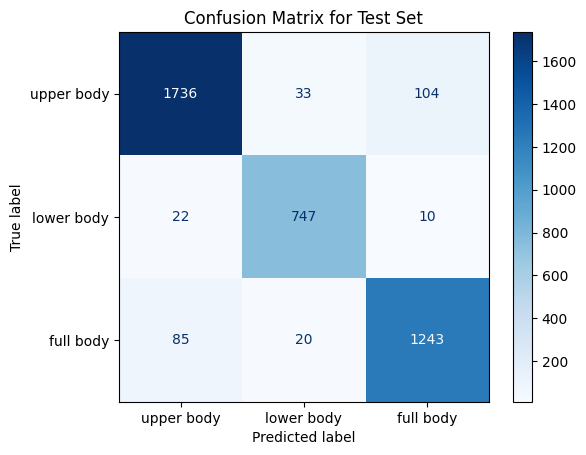

In [ ]:
test_labels = bbox_test_split['category_type_tf'].tolist()
test_pred_probs = model.predict(test_ds)
test_predictions = tf.argmax(test_pred_probs, axis=1, output_type=tf.int32)
ConfusionMatrixDisplay.from_predictions(y_true=test_labels, y_pred=test_predictions, display_labels=list(category_mapping.values()), cmap=plt.cm.Blues)
plt.title("Confusion Matrix for Test Set")

In [ ]:
total_upper_body = bbox_test_split[bbox_test_split['category_type_tf'] == 0].shape[0]
total_lower_body = bbox_test_split[bbox_test_split['category_type_tf'] == 1].shape[0]
total_full_body = bbox_test_split[bbox_test_split['category_type_tf'] == 2].shape[0]
missclassified_upper_body = sum((test_predictions.numpy() != test_labels) & (np.array(test_labels) == 0))
missclassified_lower_body = sum((test_predictions.numpy() != test_labels) & (np.array(test_labels) == 1))
missclassified_full_body = sum((test_predictions.numpy() != test_labels) & (np.array(test_labels) == 2))
print(f"Upper Body: Total = {total_upper_body}, Misclassified = {missclassified_upper_body}, Accuracy = {(total_upper_body - missclassified_upper_body) / total_upper_body:.2%}")
print(f"Lower Body: Total = {total_lower_body}, Misclassified = {missclassified_lower_body}, Accuracy = {(total_lower_body - missclassified_lower_body) / total_lower_body:.2%}")
print(f"Full Body: Total = {total_full_body}, Misclassified = {missclassified_full_body}, Accuracy = {(total_full_body - missclassified_full_body) / total_full_body:.2%}")

Upper Body: Total = 1873, Misclassified = 137, Accuracy = 92.69%
Lower Body: Total = 779, Misclassified = 32, Accuracy = 95.89%
Full Body: Total = 1348, Misclassified = 105, Accuracy = 92.21%


In [ ]:
test_true_label = []
test_pred_label =[]
for info in (misclassified_images):
    image_path = info['image_path']
    true_label_idx = info['true_label']
    predicted_label_idx = info['predicted_label']

    true_label_name = category_mapping.get(true_label_idx, "Unknown")
    predicted_label_name = category_mapping.get(predicted_label_idx, "Unknown")
    test_true_label.append(true_label_name)
    test_pred_label.append(predicted_label_name)
ConfusionMatrixDisplay.from_predictions(test_true_label, test_pred_label)
plt.title("Confusion matrix of Misclassified Images in Test")
plt.show()

Found 274 misclassified images out of 4000.


In [ ]:
from sklearn.metrics import f1_score
test_labels = bbox_test_split['category_type_tf'].tolist()
test_pred_probs = model_loaded.predict(test_ds)
test_predictions = tf.argmax(test_pred_probs, axis=1, output_type=tf.int32)
f1score = f1_score(test_labels, test_predictions, average='weighted')
print(f"Weighted F1 Score on Test Set: {f1score:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step
Weighted F1 Score on Test Set: 0.9315
